In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))

import time
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar

In [2]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.add_compiler("../code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 55676
正在编译文件:  ../code/read_point3.txt
正在编译文件:  ../code/read_point3_col.txt
正在编译文件:  ../code/row_read_point3.txt
正在编译文件:  ../code/set_reset.txt
正在编译文件:  ../code/write_verify.txt
正在编译文件:  ../code/汇编测试代码.txt
正在编译文件:  ../code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ../code/读单点测试.txt


In [3]:
set_good_device_file_name = "../data/cond_500_1_4.npy"
reset_good_device_file_name = "../data/cond_200_1_4.npy"

# 1.set操作

In [ ]:
pos = (0,256,0,256)
chip.write_point3(*pos,write_voltage=3,tg=1.6,pulse_width=1e-6,set_device=True)

In [ ]:
pos = (0,256,0,256)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
plot_cond(cond,title="cond",vmin=0,vmax=1500)

# 2.reset操作

In [ ]:
# # 对某一块区域内的点进行reset
# pos = (0,256,0,256)
# chip.write_point3(*pos,write_voltage=3,tg=1.6,pulse_width=1e-6,set_device=False)

In [ ]:
def Reset(write_times,start_v,delta_v,tg,threshold,reset_pulse_width,read_type=2,sub_base=False,vmax=1000):
    need_read = np.ones((256,256),dtype=bool)
    voltage_base = np.zeros((256,256))
    voltage = np.zeros((256,256))
    cond_sub_base = None
    for i in range(write_times):
        print(f"write_time = {i}")
        v = start_v+i*delta_v
        if read_type == 2:
            if sub_base:
                voltage_base[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)[need_read]
            voltage[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)[need_read]
        elif read_type == 3:
            pos = (0,256,0,256)
            if sub_base:
                voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
            voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
        if sub_base:
            cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
        else:
            cond_sub_base = chip.voltage_to_cond(voltage)

        condition_reset = cond_sub_base>threshold
        need_read = condition_reset

        plot_cond(cond_sub_base,title=f"v={v:.2f}-needReset={np.sum(condition_reset)}",vmax=vmax)

        chip.write_point2(crossbar=condition_reset,write_voltage=v,tg=tg,pulse_width=reset_pulse_width,set_device=False)

In [ ]:
Reset(51,start_v=1,delta_v=0.05,tg=5,threshold=200,reset_pulse_width=1e-6,read_type=2,sub_base=True)

In [ ]:
pos = (0,256,0,256)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
print(np.sum(cond<200))
np.save(reset_good_device_file_name,cond<200)

In [ ]:
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)-700
plot_cond(cond,vmin=-500,vmax=500)

interval = 5
bin_edges = np.linspace(-1000, 1000, int(2000/interval)+1)  
data = cond.flatten()
counts, bin_edges, _ = plt.hist(data, bins=bin_edges, color='blue', alpha=0.7, edgecolor='None')

# 3.Forming器件

In [ ]:
# # 对某一块区域内的点进行set
# pos = (0,256,0,256)
# chip.write_point3(*pos,write_voltage=3,tg=1.6,pulse_width=1e-6,set_device=True)

In [ ]:
def Forming(write_times,write_voltage,start_tg,delta_tg,threshold,set_pulse_width,read_type=2,sub_base=False):
    need_read = np.ones((256,256),dtype=bool)
    voltage_base = np.zeros((256,256))
    voltage = np.zeros((256,256))
    cond_sub_base = None
    for i in range(write_times):
        print(f"write_time = {i}")
        tg = start_tg+i*delta_tg
        if read_type == 2:
            if sub_base:
                voltage_base[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)[need_read]
            voltage[need_read] = chip.read_point2(crossbar=need_read, read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)[need_read]
        elif read_type == 3:
            pos = (0,256,0,256)
            if sub_base:
                voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
            voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
        if sub_base:
            cond_sub_base = chip.voltage_to_cond(voltage-voltage_base)
        else:
            cond_sub_base = chip.voltage_to_cond(voltage)



        condition_set = cond_sub_base<threshold
        need_read = condition_set

        plot_cond(cond_sub_base,title=f"tg={tg:.2f}-needForming={np.sum(condition_set)}",vmax=1200)
        # if i==0:
        #     chip.write_point2(crossbar=condition_set,write_voltage=5,tg=2.5,pulse_width=1e-6,set_device=False)
        # set的点
        chip.write_point2(crossbar=condition_set,write_voltage=write_voltage,tg=tg,pulse_width=set_pulse_width,set_device=True)

In [ ]:
chip.ps.set_time_out(10)
for i in range(1):
    Forming(write_times=47,write_voltage=5,start_tg=0.7,delta_tg=0.05,threshold=550,set_pulse_width=10e-6,read_type=2,sub_base=True)

In [ ]:
pos = (0,256,0,256)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
print(np.sum(cond>500))
np.save(set_good_device_file_name,cond>500)

# 3.寻找好的区域

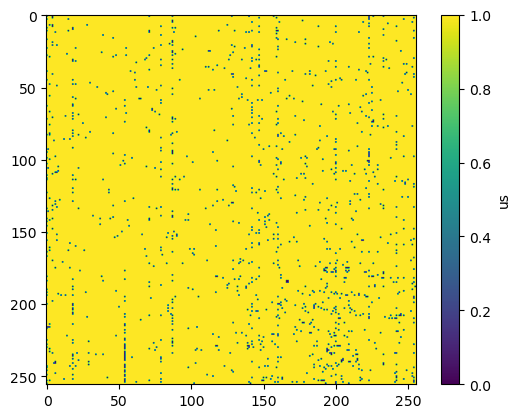

In [5]:
cond_200 = np.load(reset_good_device_file_name)
cond_500 = np.load(set_good_device_file_name)
good_cond = cond_200&cond_500
plot_cond(good_cond,vmax=1)

[  0   1   2   4   6   7   8  15  16  18  20  22  28  29  39  46  48  54
  55  59  62  69  71  74  75  76  79  84  87  89  90  94  98 101 102 103
 112 115 117 118 119 125 126 127 128 129 130 132 133 134 135 138 139 140
 141 142 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160
 161 162 163 164 165 166 167 168 170 171 172 173 174 175 176 177 178 179
 180 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 229 231 233 236 237 238 241
 242 243 244 245 246 247 248 249 250 252 253 254]
[[ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 ...
 [ True  True  True  True  True]
 [ True  True  True  True  True]
 [ True  True  True  True  True]]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 3 1 1 1
 1 2 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2
 1 1 1 1 1 1

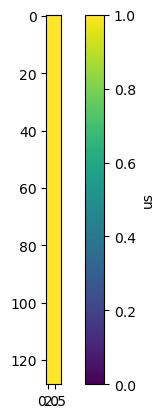

In [6]:
# 可以选最大的0-100行里面的5列
col = np.sum(good_cond,axis=0)
col = np.argsort(col)[:-100]
col = np.sort(col)
print(col)
col = np.array([246,247,248,249,250])

good_device = np.load("../data/good_point_100_100_1_4.npy")

row = good_cond[:, col]
print(row)
row = np.sum(row,axis=1)
row = np.argsort(row)[50:]
row = np.sort(row)[3:132]
# row = np.arange(3,131)
print(np.diff(row))

print("选择的行",row)

print("选择的列",col)

sub_matrix = good_cond[np.ix_(row, col)]
print(np.sum(sub_matrix))
plot_cond(sub_matrix,vmax=1)


In [150]:
np.savez("../data/svm/svm_weight_pos",row=row,col=col)
# a=np.load("../data/svm/svm_weight_pos.npz")
# print(a["row"])

In [109]:
print(np.ix_(row,col)[1])

[[ 31  33  81  93 108]]


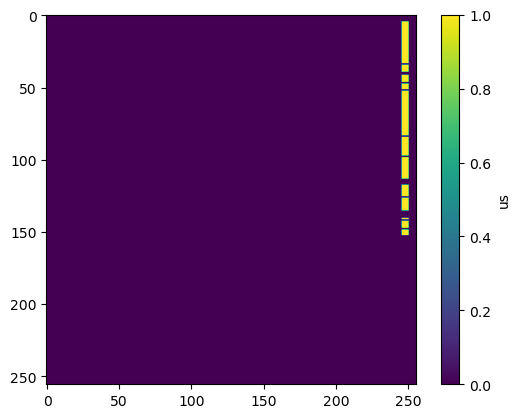

[  3   5   9  10  11  12  13  14  17  19  21  23  24  25  26  27  30  31
  32  33  34  35  36  37  38  40  41  42  43  44  45  47  49  50  51  52
  53  56  57  58  60  61  63  64  65  66  67  68  70  72  73  77  78  80
  81  82  83  85  86  88  91  92  93  95  96  97  99 100 104 105 106 107
 108 109 110 111 113 114 116 120 121 122 123 124 131 136 137 143 144 169
 181 228 230 232 234 235 239 240 251 255]


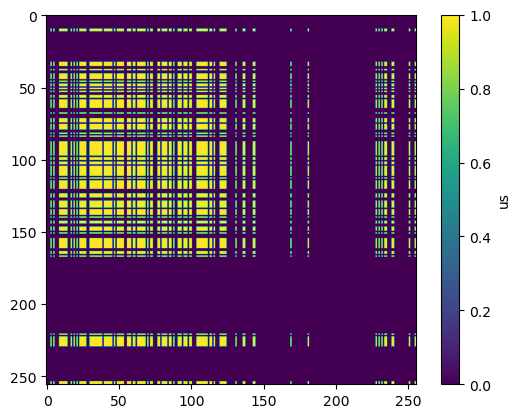

0


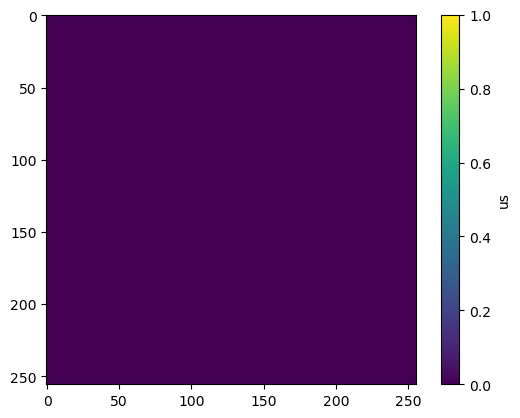

In [7]:
pos0 = np.zeros((256,256))
pos0[np.ix_(row,col)]=1
plot_cond(pos0,vmax=1)

good_device = np.load("../data/good_point_100_100_1_4.npy")
print(good_device[1])
pos1 = np.zeros((256,256))
pos1[np.ix_(good_device[0],good_device[1])]=1
plot_cond(pos1,vmax=1)

print(np.sum((pos0>0)&(pos1>0)))
plot_cond((pos0>0.5)&(pos1>0.5),vmax=1)